In [1]:
!pip install pandas numpy matplotlib statsmodels

# Import them
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
# Generate 3 years of monthly sales data
np.random.seed(42)
dates = pd.date_range(start='2021-01-01', periods=36, freq='MS')
sales  = 200 + np.arange(36) * 3 + np.random.normal(0, 15, 36)

df = pd.DataFrame({'date': dates, 'sales': sales})
df.set_index('date', inplace=True)

print(df.head(10))  # Preview first 10 rows

                 sales
date                  
2021-01-01  207.450712
2021-02-01  200.926035
2021-03-01  215.715328
2021-04-01  231.845448
2021-05-01  208.487699
2021-06-01  211.487946
2021-07-01  241.688192
2021-08-01  232.511521
2021-09-01  216.957884
2021-10-01  235.138401


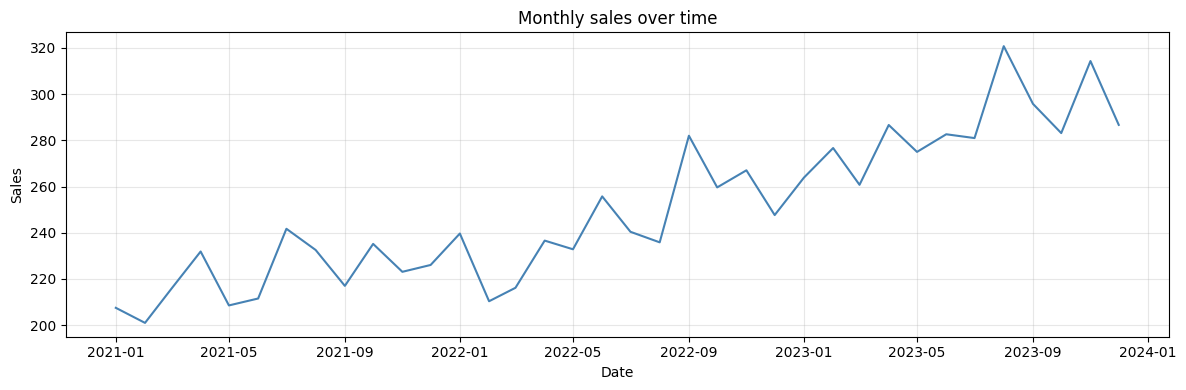

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['sales'], color='steelblue', linewidth=1.5)
plt.title('Monthly sales over time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['sales'])
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')

if result[1] < 0.05:
    print('Result: Stationary — ready for ARIMA')
else:
    print('Result: NOT stationary — apply differencing')
    df['sales_diff'] = df['sales'].diff().dropna()

ADF Statistic : 1.6191
p-value       : 0.9979
Result: NOT stationary — apply differencing


In [5]:
# Fit ARIMA(1, 1, 1)
model = ARIMA(df['sales'], order=(1, 1, 1))
result = model.fit()

# Summary of the model
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -147.481
Date:                Thu, 04 Jun 2026   AIC                            300.962
Time:                        12:30:47   BIC                            305.628
Sample:                    01-01-2021   HQIC                           302.572
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2083      0.381     -0.547      0.584      -0.955       0.538
ma.L1         -0.4695      0.331     -1.417      0.157      -1.119       0.180
sigma2       263.9769     64.267      4.107      0.0

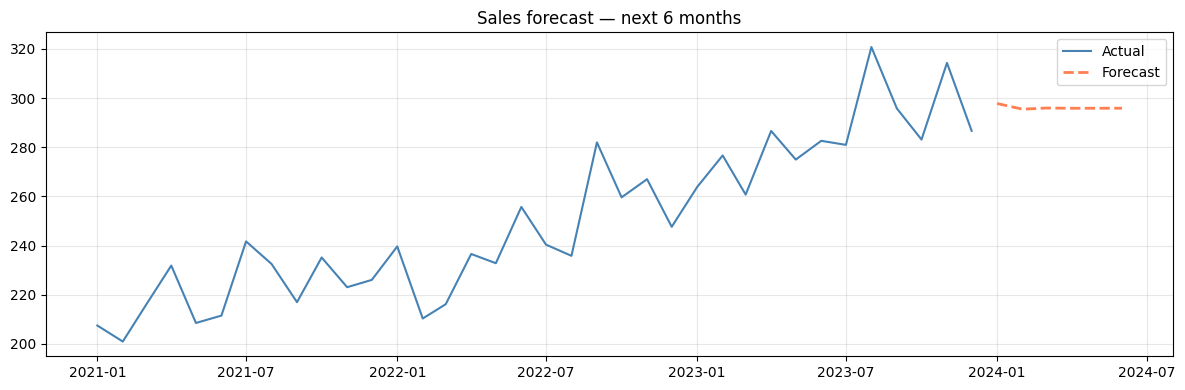

Forecasted values:
2024-01-01    297.81
2024-02-01    295.49
2024-03-01    295.97
2024-04-01    295.87
2024-05-01    295.89
2024-06-01    295.89
Freq: MS, Name: predicted_mean, dtype: float64


In [6]:
# Forecast next 6 months
forecast = result.forecast(steps=6)
forecast_index = pd.date_range(
    start=df.index[-1], periods=7, freq='MS')[1:]

# Plot actual + forecast
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['sales'],
         label='Actual', color='steelblue')
plt.plot(forecast_index, forecast,
         label='Forecast', color='coral',
         linestyle='--', linewidth=2)
plt.title('Sales forecast — next 6 months')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Forecasted values:')
print(forecast.round(2))

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# In-sample predictions (on training data)
predictions = result.fittedvalues

# Drop first row (NaN due to differencing)
actual    = df['sales'].iloc[1:]
predicted = predictions.iloc[1:]

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'Avg sales: {actual.mean():.2f}')

MAE  : 12.87
RMSE : 16.27
Avg sales: 251.27
